In [1]:
import os
import sys
import shutil

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import yaml
from chroma import structure, plotting
from OpenMiChroM.CndbTools import cndbTools
import seaborn as sns

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

plt.style.use("chroma.tex")

# nuclear bodies as beads

## chr1

In [14]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 32
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

chromosome = 1

folder_num = 4 if chromosome == 1 else 5

OUTPUT_FOLDER = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/7_analysis/sasa/data"

In [15]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [16]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [17]:
title = {
    "complete": r"$\in\,\text{lamina}$",
    "nucleolus": r"$\notin\,\text{lamina}$",
}

In [18]:
# for testing the figures:
# mpl.rcParams["figure.dpi"] = 300

### Concatenating the data


In [19]:
sasa = {}
for condition in conditions:
    sasa[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing condition {condition}: replica {replica}")
        with h5py.File(
            os.path.join(
                OUTPUT_FOLDER,
                condition,
                f"sasa-replica{replica}.h5",
            )
        ) as saved_file:
            for key in saved_file.keys():
                if key != "all":
                    if key not in sasa[condition].keys():
                        sasa[condition][key] = []
                    sasa[condition][key].append(saved_file[key][:])

    for key in sasa[condition].keys():
        sasa[condition][key] = np.concatenate(
            sasa[condition][key], axis=0
        )

Processing condition complete: replica 1
Processing condition complete: replica 2
Processing condition complete: replica 3
Processing condition complete: replica 4
Processing condition complete: replica 5
Processing condition complete: replica 6
Processing condition complete: replica 7
Processing condition complete: replica 8
Processing condition complete: replica 9
Processing condition complete: replica 10
Processing condition complete: replica 11
Processing condition complete: replica 12
Processing condition complete: replica 13
Processing condition complete: replica 14
Processing condition complete: replica 15
Processing condition complete: replica 16
Processing condition complete: replica 17
Processing condition complete: replica 18
Processing condition complete: replica 19
Processing condition complete: replica 20
Processing condition complete: replica 21
Processing condition complete: replica 22
Processing condition complete: replica 23
Processing condition complete: replica 24
P

In [20]:
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"sasa-data-aggregated.h5",
    ),
    "w",
) as saving_file:
    for condition in conditions:
        group = saving_file.create_group(condition)
        for key in sasa[condition].keys():
            group.create_dataset(
                f"{key}",
                data=sasa[condition][key],
            )

### Plotting

In [21]:
sasa = {}
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"sasa-data-aggregated.h5",
    ),
    "r",
) as saved_file:
    for condition in saved_file.keys():
        sasa[condition] = {}
        group = saved_file[condition]
        for key in group.keys():
            sasa[condition][key] = group[key][:]

In [29]:
sasa[condition]["B"].

487139000.0

In [32]:
np.histogram(sasa[condition]["B"])

(array([   103,   2585,  22287,  77557, 112936,  75777,  24573,   3882,
           294,      6]),
 array([1144.4097, 1227.946 , 1311.4823, 1395.0187, 1478.5549, 1562.0913,
        1645.6277, 1729.164 , 1812.7003, 1896.2366, 1979.773 ],
       dtype=float32))

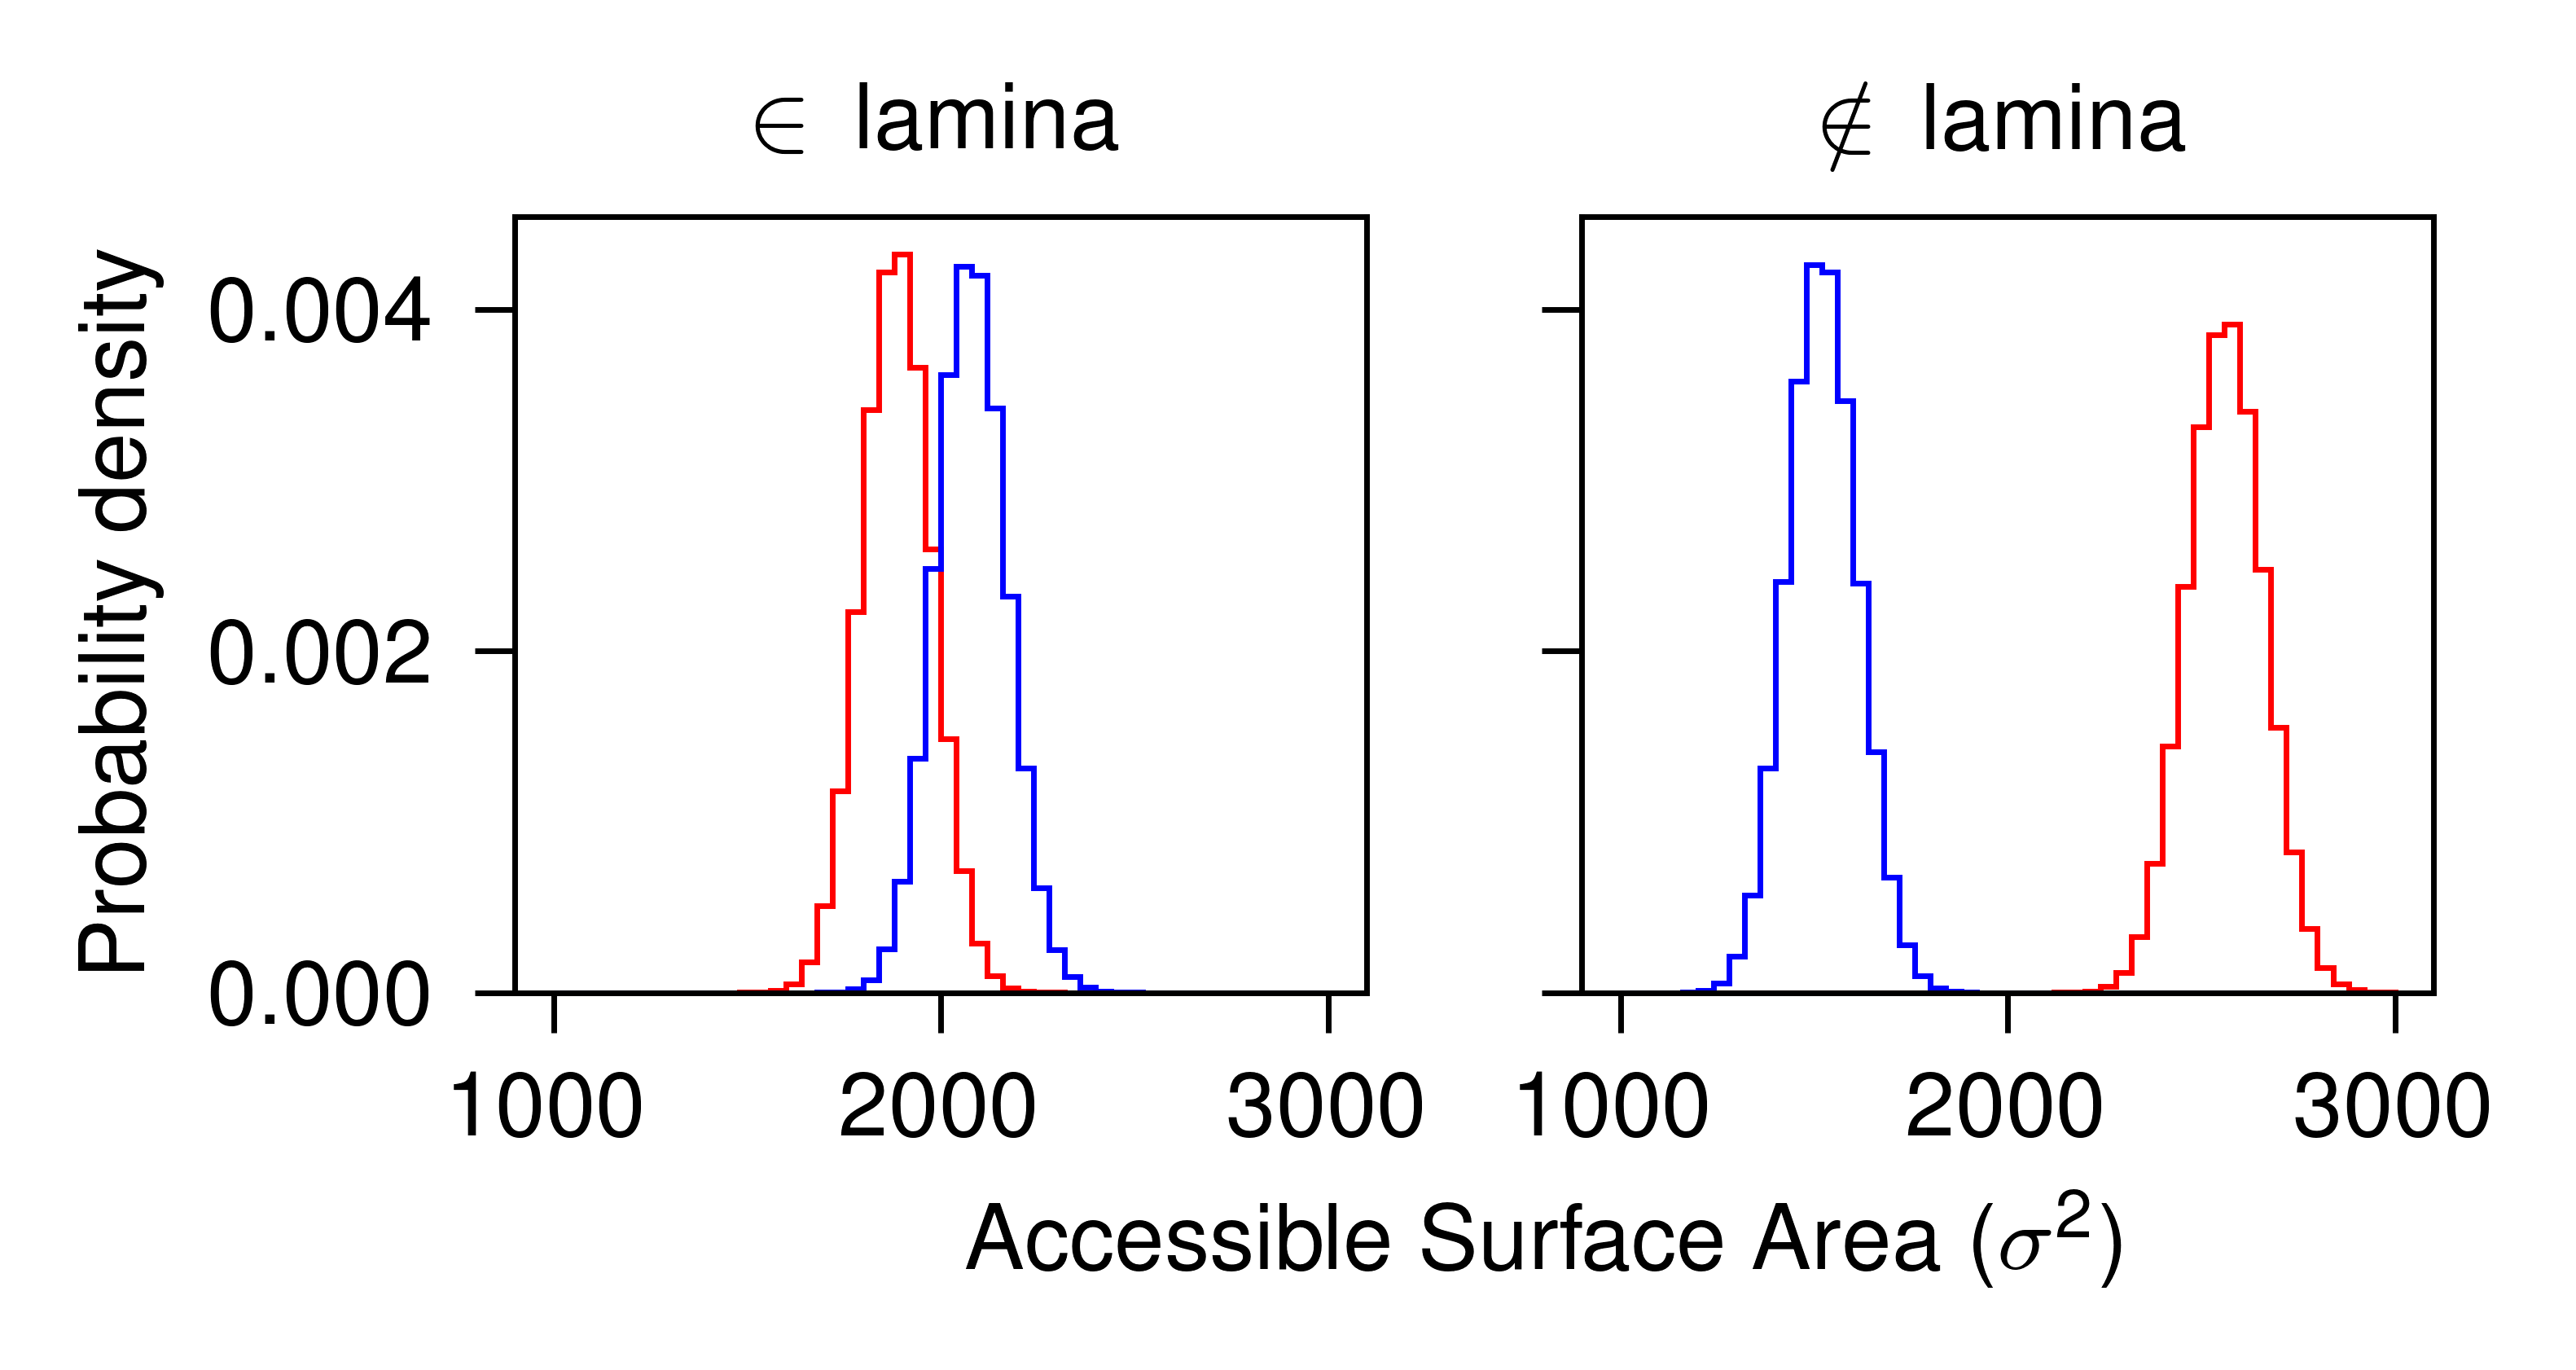

In [52]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(3.2, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(1000, 3000, 50 + 1)

for i, condition in enumerate(["complete", "nucleolus"]):
    ax[i].set_title(title[condition], fontsize=8)

    ax[i].hist(
        sasa[condition]["A"],
        bins=bins,
        label="A",
        density=True,
        color="red",
        histtype="step",
    )
    ax[i].hist(
        sasa[condition]["B"],
        bins=bins,
        label="B",
        density=True,
        color="blue",
        histtype="step",
    )

ax[0].set_ylabel("Probability density")
ax[0].set_xticks([1000, 2000, 3000])

fig.supxlabel(
    r"Accessible Surface Area ($\sigma^2$)",
    y=0.11,
    x=0.60,
    fontsize=8,
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

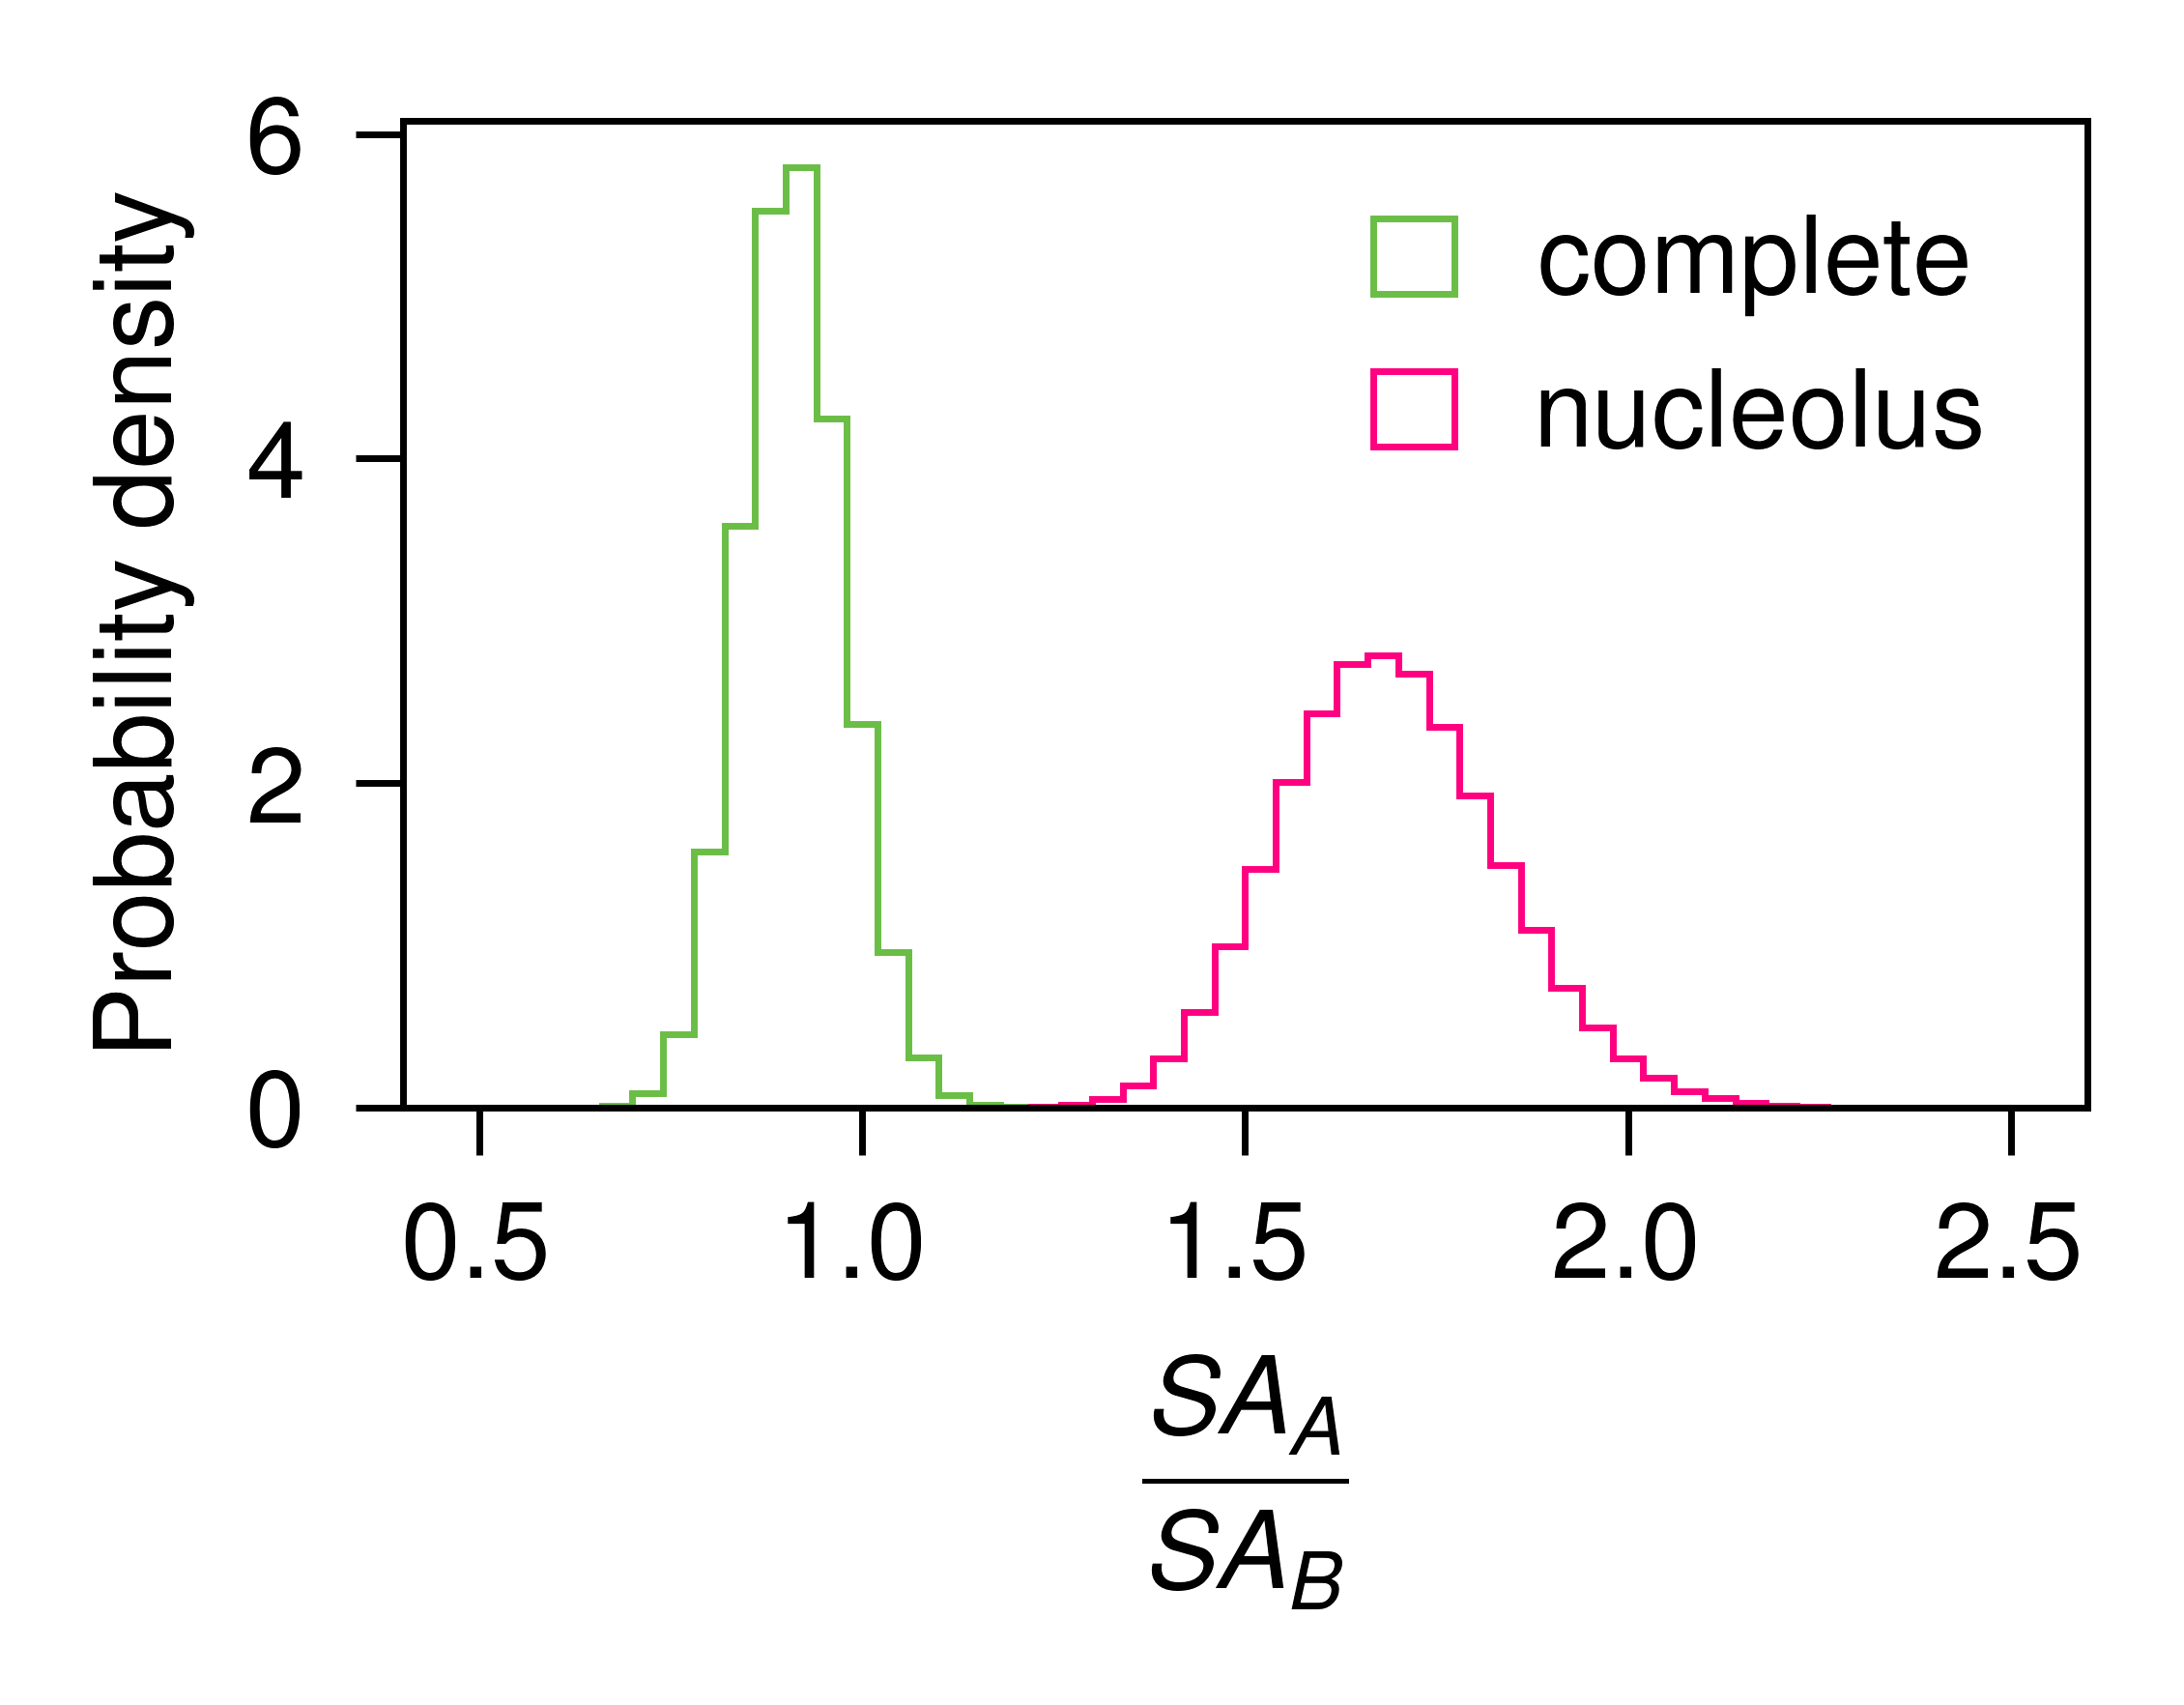

In [60]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(2.3, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0.5, 2.5, 50 + 1)
# bins = 50

for i, condition in enumerate(["complete", "nucleolus"]):
    ax.hist(
        sasa[condition]["A"] / sasa[condition]["B"],
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
        histtype="step",
    )

ax.set_ylabel("Probability density")
# ax[0].set_xticks([1000, 2000, 3000])

ax.set_xlabel(r"$\dfrac{SA_A}{SA_B}$")
ax.legend(loc="upper right", frameon=False, handlelength=0.75)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

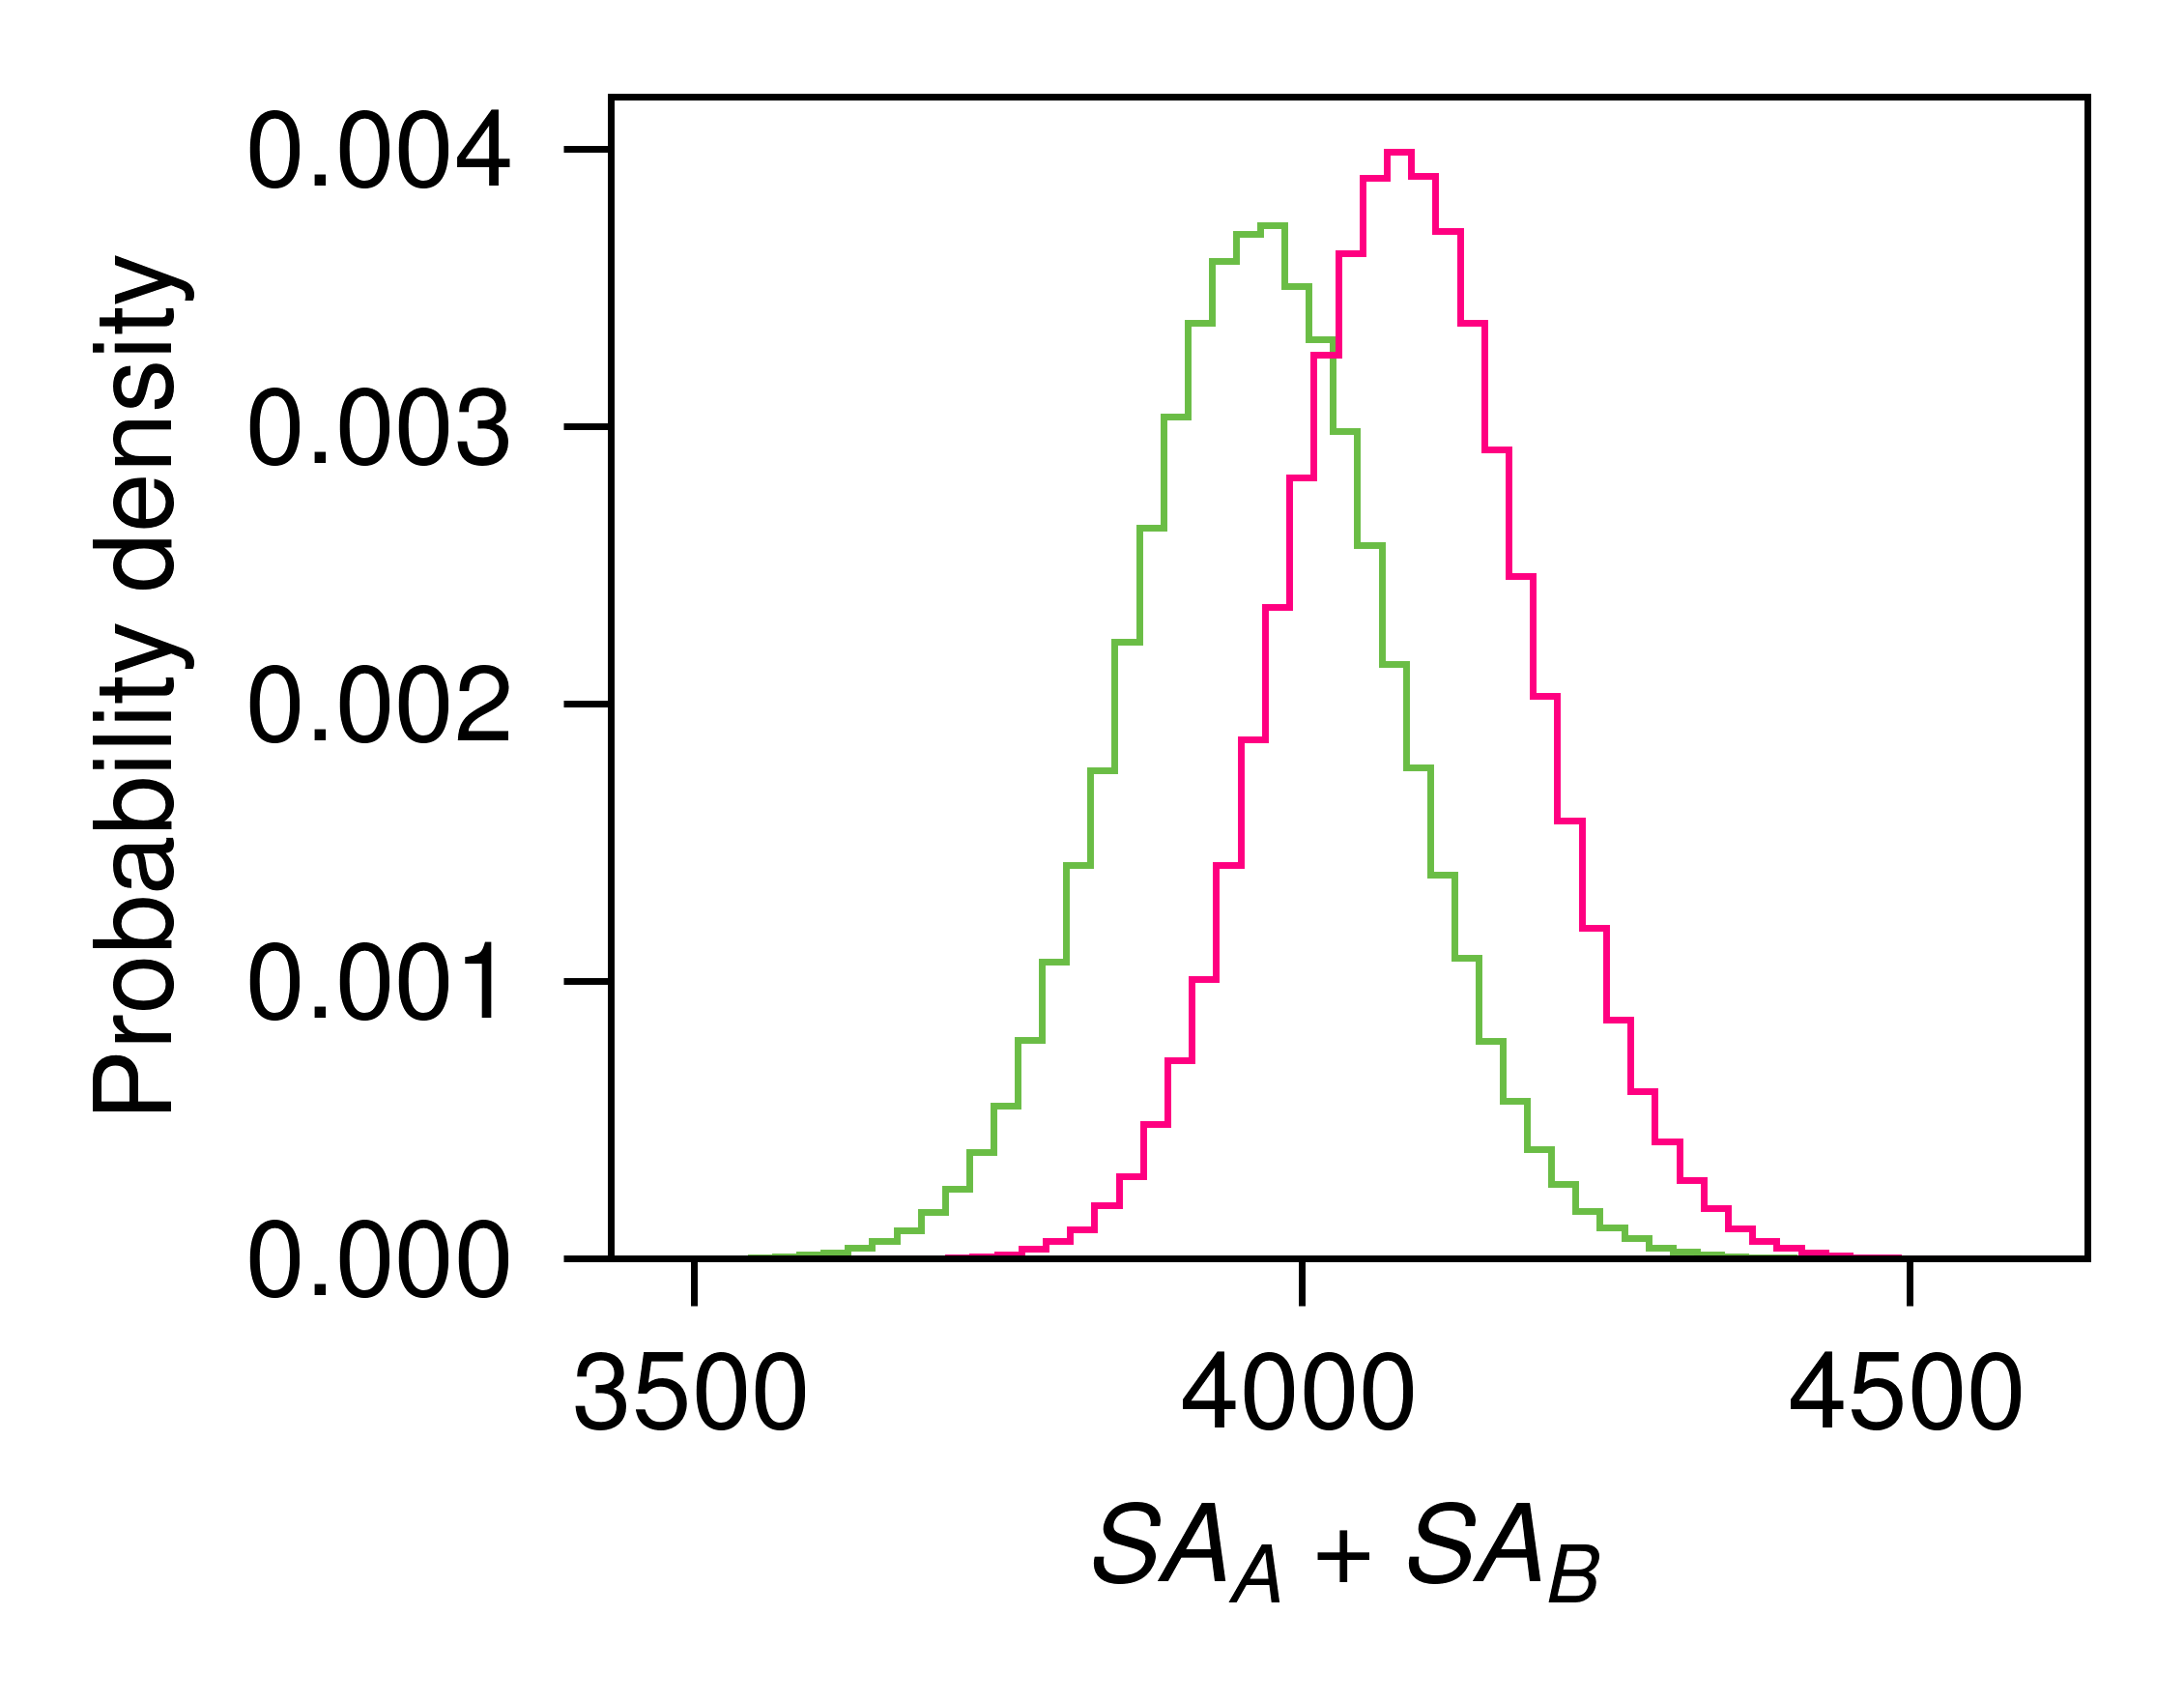

In [62]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(2.3, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

# bins = np.linspace(0.5, 2.5, 50 + 1)
bins = 50

for i, condition in enumerate(["complete", "nucleolus"]):
    ax.hist(
        sasa[condition]["A"] + sasa[condition]["B"],
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
        histtype="step",
    )

ax.set_ylabel("Probability density")
# ax[0].set_xticks([1000, 2000, 3000])

ax.set_xlabel(r"$SA_A + SA_B$")
# ax.legend(loc="upper right", frameon=False, handlelength=0.75)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")